In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
Keras version: 3.14.0
GPU available: []


# Animal Image Classification with Deep Learning
## A Keras/TensorFlow Project following Chollet's Universal Workflow

In [ ]:
# Load CIFAR-10 dataset from Keras datasets
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Class names for all 10 CIFAR-10 classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training images shape:", x_train.shape)
print("Test images shape:", x_test.shape)
print("Total training samples:", len(x_train))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 88s 1us/step


c:\Users\hrojk\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training images shape: (50000, 32, 32, 3)
Test images shape: (10000, 32, 32, 3)
Total training samples: 50000


Animal training samples: 30000
Animal test samples: 6000


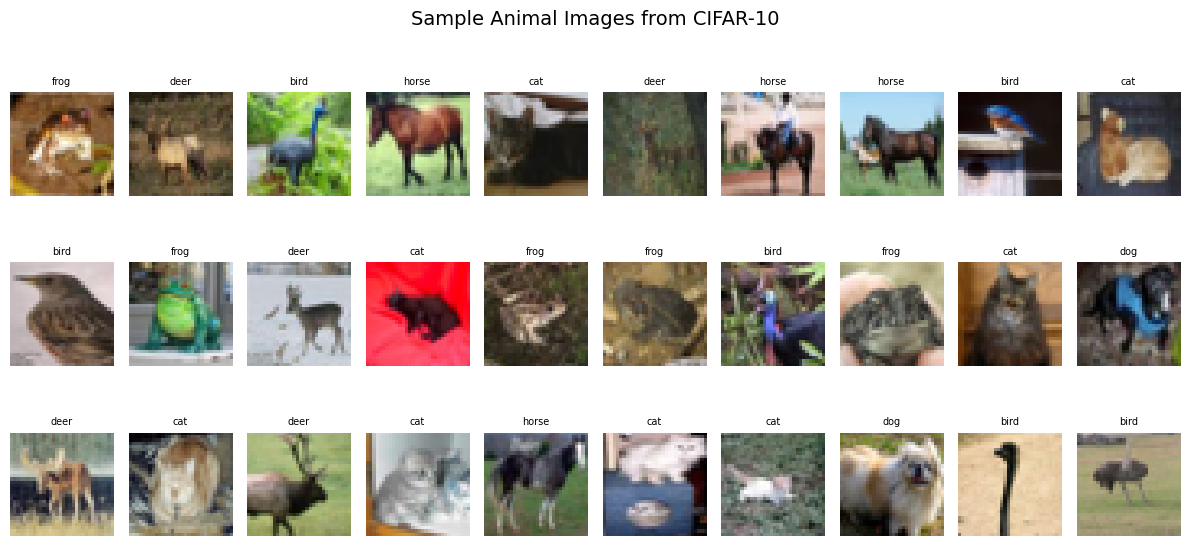

In [3]:
# Filter to animal classes only (bird, cat, deer, dog, frog, horse)
animal_classes = [2, 3, 4, 5, 6, 7]  # their index numbers in CIFAR-10
animal_names = ['bird', 'cat', 'deer', 'dog', 'frog', 'horse']

# Create a mask to keep only animal images
train_mask = np.isin(y_train.flatten(), animal_classes)
test_mask = np.isin(y_test.flatten(), animal_classes)

x_train_animals = x_train[train_mask]
y_train_animals = y_train[train_mask]
x_test_animals = x_test[test_mask]
y_test_animals = y_test[test_mask]

# Remap labels to 0-5 instead of 2-7
for i, cls in enumerate(animal_classes):
    y_train_animals = np.where(y_train_animals == cls, i, y_train_animals)
    y_test_animals = np.where(y_test_animals == cls, i, y_test_animals)

print("Animal training samples:", len(x_train_animals))
print("Animal test samples:", len(x_test_animals))

# Plot some sample images
plt.figure(figsize=(12, 6))
for i in range(30):
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_train_animals[i])
    plt.title(animal_names[y_train_animals[i][0]], fontsize=7)
    plt.axis('off')
plt.suptitle("Sample Animal Images from CIFAR-10", fontsize=14)
plt.tight_layout()
plt.savefig('outputs/sample_images.png')
plt.show()

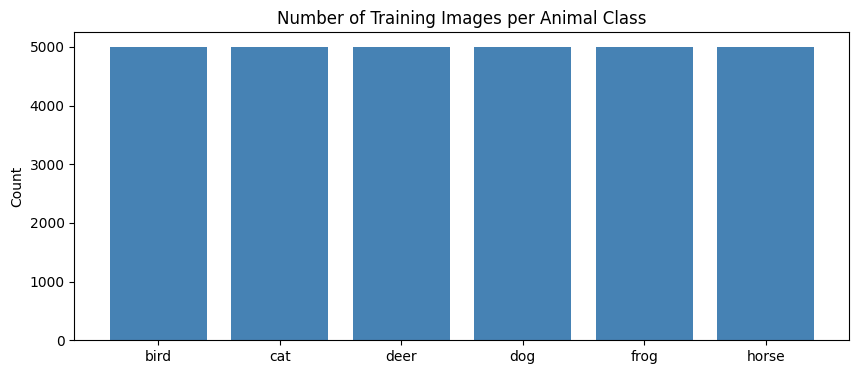

Class counts: {'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000)}

Pixel value range before: 0 - 255
Pixel value range after: 0.0 - 1.0


In [ ]:
# Check class balance 
plt.figure(figsize=(10, 4))
counts = [np.sum(y_train_animals == i) for i in range(6)]
plt.bar(animal_names, counts, color='steelblue')
plt.title('Number of Training Images per Animal Class')
plt.ylabel('Count')
plt.savefig('outputs/class_distribution.png')
plt.show()
print("Class counts:", dict(zip(animal_names, counts)))

# Normalise pixel values from 0-255 to 0-1 
x_train_norm = x_train_animals.astype('float32') / 255.0
x_test_norm = x_test_animals.astype('float32') / 255.0

print("\nPixel value range before:", x_train_animals.min(), "-", x_train_animals.max())
print("Pixel value range after:", x_train_norm.min(), "-", x_train_norm.max())

## Section 2: Baseline Model
A simple CNN with no regularisation tricks. We expect it to overfit — that's the point!

In [5]:
from tensorflow import keras
from tensorflow.keras import layers

def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(6, activation='softmax')  # 6 animal classes
    ])
    return model

model_baseline = build_baseline_model()
model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,310 (477.77 KB)

 Trainable params: 122,310 (477.77 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile and train the baseline model
model_baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = model_baseline.fit(
    x_train_norm, y_train_animals,
    epochs=20,
    batch_size=64,
    validation_split=0.2,  # 20% of training data used for validation
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3846 - loss: 1.4960 - val_accuracy: 0.4852 - val_loss: 1.3122
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5236 - loss: 1.2357 - val_accuracy: 0.5567 - val_loss: 1.1429
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5838 - loss: 1.0966 - val_accuracy: 0.5793 - val_loss: 1.1135
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6200 - loss: 1.0070 - val_accuracy: 0.6212 - val_loss: 1.0097
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6494 - loss: 0.9409 - val_accuracy: 0.6325 - val_loss: 0.9804
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6727 - loss: 0.8762 - val_accuracy: 0.6453 - val_loss: 0.9451
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6957 - loss: 0.8287 - val_accuracy: 0.6590 - val_loss: 0.9309
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7101 - loss: 0.7847 - val_accura

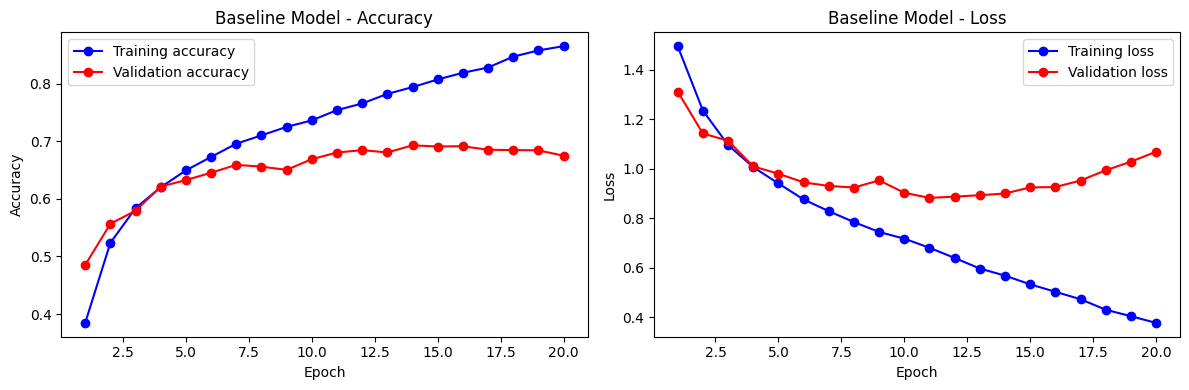

Final training accuracy:   0.865
Final validation accuracy: 0.675


In [7]:
# Plot training vs validation accuracy and loss
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'outputs/{title.replace(" ", "_")}.png')
    plt.show()

plot_history(history_baseline, 'Baseline Model')

# Print final scores
print(f"Final training accuracy:   {history_baseline.history['accuracy'][-1]:.3f}")
print(f"Final validation accuracy: {history_baseline.history['val_accuracy'][-1]:.3f}")

## Section 3: Fighting Overfitting

The baseline model overfits significantly (86% train vs 68% val accuracy).
We will try three techniques: Dropout, Batch Normalisation, and Data Augmentation.

### Experiment A: Adding Dropout

In [8]:
def build_dropout_model():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dropout(0.5),  # <-- randomly turns off 50% of neurons
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(6, activation='softmax')
    ])
    return model

model_dropout = build_dropout_model()
model_dropout.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

history_dropout = model_dropout.fit(
    x_train_norm, y_train_animals,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3231 - loss: 1.6119 - val_accuracy: 0.4433 - val_loss: 1.3802
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4828 - loss: 1.3202 - val_accuracy: 0.5552 - val_loss: 1.1730
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5348 - loss: 1.2051 - val_accuracy: 0.5675 - val_loss: 1.1435
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5724 - loss: 1.1246 - val_accuracy: 0.6033 - val_loss: 1.0329
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5983 - loss: 1.0619 - val_accuracy: 0.6120 - val_loss: 1.0272
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6156 - loss: 1.0244 - val_accuracy: 0.5978 - val_loss: 1.0342
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6327 - loss: 0.9834 - val_accuracy: 0.6405 - val_loss: 0.9462
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6448 - loss: 0.9547 - val_accu

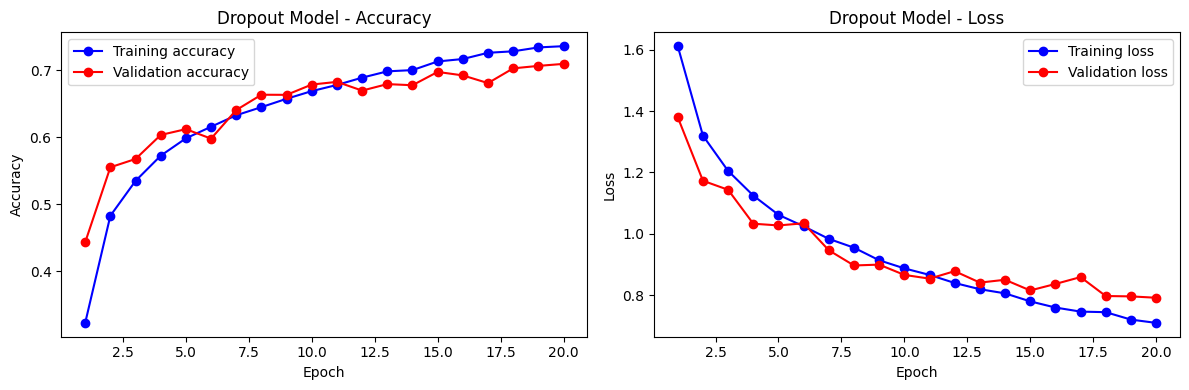

Baseline  - Train: 0.865 | Val: 0.675
Dropout   - Train: 0.736 | Val: 0.709


In [9]:
plot_history(history_dropout, 'Dropout Model')

print(f"Baseline  - Train: {history_baseline.history['accuracy'][-1]:.3f} | Val: {history_baseline.history['val_accuracy'][-1]:.3f}")
print(f"Dropout   - Train: {history_dropout.history['accuracy'][-1]:.3f} | Val: {history_dropout.history['val_accuracy'][-1]:.3f}")

### Experiment B: Data Augmentation

In [10]:
# Data augmentation - artificially creates more training variety
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def build_augmented_model():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        data_augmentation,
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dense(6, activation='softmax')
    ])
    return model

model_augmented = build_augmented_model()
model_augmented.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

history_augmented = model_augmented.fit(
    x_train_norm, y_train_animals,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3391 - loss: 1.5728 - val_accuracy: 0.4265 - val_loss: 1.4290
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4592 - loss: 1.3657 - val_accuracy: 0.4897 - val_loss: 1.3030
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4968 - loss: 1.2894 - val_accuracy: 0.5258 - val_loss: 1.2154
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5233 - loss: 1.2326 - val_accuracy: 0.5650 - val_loss: 1.1290
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5386 - loss: 1.1893 - val_accuracy: 0.5603 - val_loss: 1.1246
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5551 - loss: 1.1542 - val_accuracy: 0.5813 - val_loss: 1.0863
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5665 - loss: 1.1289 - val_accuracy: 0.5983 - val_loss: 1.0380
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5778 - loss: 1.1126 - val_accu

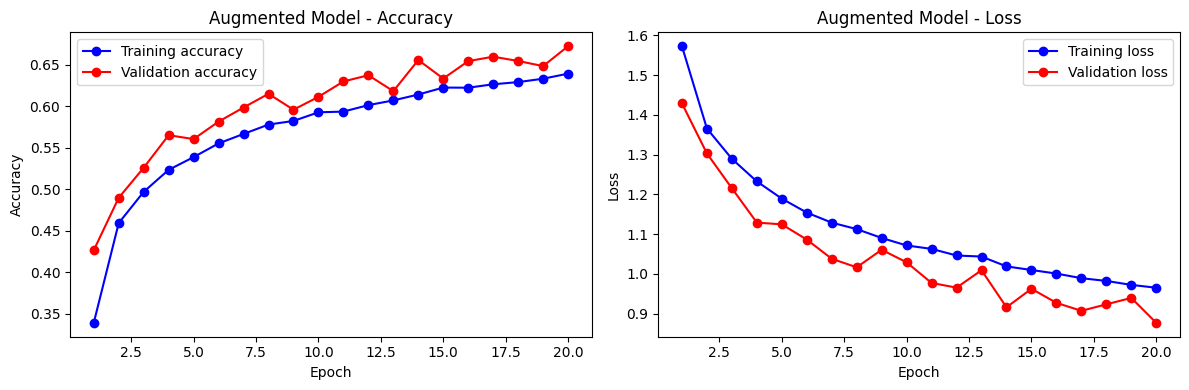

Baseline   - Train: 0.865 | Val: 0.675
Dropout    - Train: 0.736 | Val: 0.709
Augmented  - Train: 0.639 | Val: 0.672


In [11]:
plot_history(history_augmented, 'Augmented Model')

print(f"Baseline   - Train: {history_baseline.history['accuracy'][-1]:.3f} | Val: {history_baseline.history['val_accuracy'][-1]:.3f}")
print(f"Dropout    - Train: {history_dropout.history['accuracy'][-1]:.3f} | Val: {history_dropout.history['val_accuracy'][-1]:.3f}")
print(f"Augmented  - Train: {history_augmented.history['accuracy'][-1]:.3f} | Val: {history_augmented.history['val_accuracy'][-1]:.3f}")

## Section 4: Hyperparameter Search
Systematically testing different learning rates to find the best one.


Training with learning rate: 0.01
  Best val accuracy: 0.172

Training with learning rate: 0.001
  Best val accuracy: 0.699

Training with learning rate: 0.0001
  Best val accuracy: 0.574


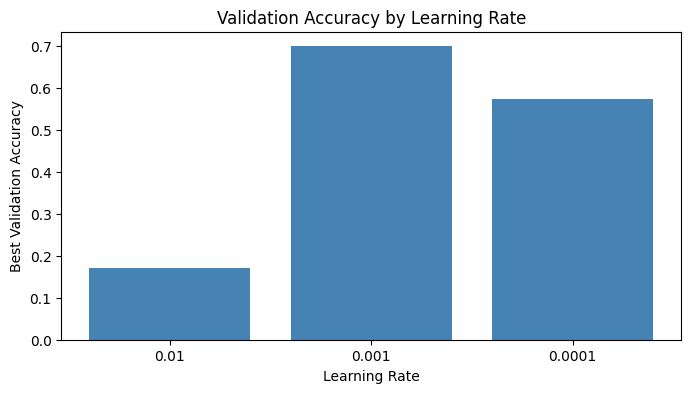


Best learning rate: 0.001 with val accuracy: 0.699


In [12]:
# Try different learning rates and compare validation accuracy
learning_rates = [0.01, 0.001, 0.0001]
lr_results = {}

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    model = build_dropout_model()
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    history = model.fit(
        x_train_norm, y_train_animals,
        epochs=15,
        batch_size=64,
        validation_split=0.2,
        verbose=0  # silent training
    )
    val_acc = max(history.history['val_accuracy'])
    lr_results[lr] = val_acc
    print(f"  Best val accuracy: {val_acc:.3f}")

# Plot results
plt.figure(figsize=(8, 4))
plt.bar([str(lr) for lr in learning_rates], lr_results.values(), color='steelblue')
plt.title('Validation Accuracy by Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Best Validation Accuracy')
plt.savefig('outputs/learning_rate_search.png')
plt.show()

best_lr = max(lr_results, key=lr_results.get)
print(f"\nBest learning rate: {best_lr} with val accuracy: {lr_results[best_lr]:.3f}")

## Section 5: Transfer Learning with MobileNetV2
Using a model pre-trained on ImageNet to dramatically boost performance.

In [13]:
from tensorflow.keras.applications import MobileNetV2

# Load MobileNetV2 pre-trained on ImageNet, without its top layer
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)  # MobileNetV2 needs bigger images
)
base_model.trainable = False  # Freeze - don't change pretrained weights

# Resize our images to 96x96 for MobileNetV2
x_train_resized = tf.image.resize(x_train_norm, (96, 96))
x_test_resized = tf.image.resize(x_test_norm, (96, 96))

# Build the full model
inputs = keras.Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(6, activation='softmax')(x)
model_transfer = keras.Model(inputs, outputs)

model_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training transfer learning model...")
history_transfer = model_transfer.fit(
    x_train_resized, y_train_animals,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training transfer learning model...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 45s 113ms/step - accuracy: 0.6244 - loss: 1.0509 - val_accuracy: 0.7345 - val_loss: 0.7319
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 113ms/step - accuracy: 0.7195 - loss: 0.7736 - val_accuracy: 0.7543 - val_loss: 0.6850
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 114ms/step - accuracy: 0.7318 - loss: 0.7359 - val_accuracy: 0.7415 - val_loss: 0.7012
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 116ms/step - accuracy: 0.7417 - loss: 0.7135 - val_accuracy: 0.7648 - val_loss: 0.6603
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 115ms/step - accuracy: 0.7452 - loss: 0.7041 - val_accuracy: 0.7663 - val_loss: 0.6600
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 115ms/step - accuracy: 0.7434 - loss: 0.6979 - val_accuracy: 0.7608 - val_loss: 0.6639
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 116ms/step - accuracy: 0.7471 - loss: 0.6934 - val_accuracy: 0.7667 - val_loss: 0.646

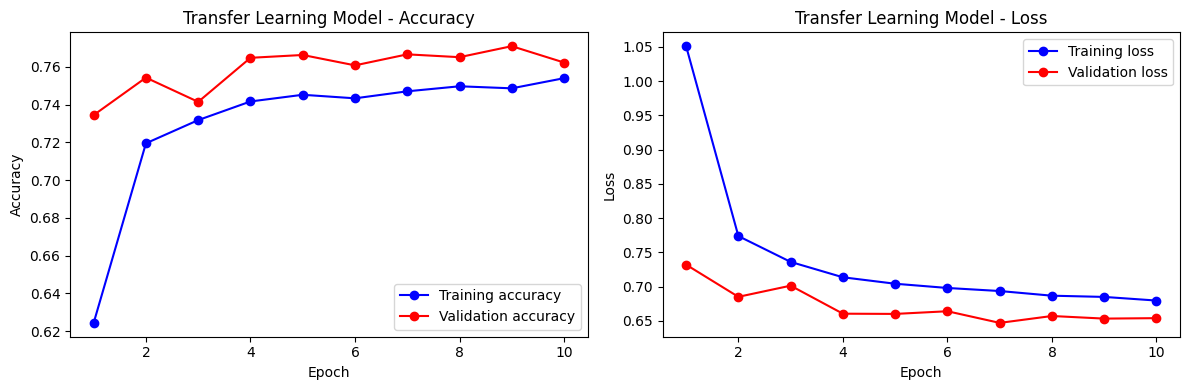

FULL RESULTS SUMMARY
Baseline       - Train: 0.865 | Val: 0.675
Dropout        - Train: 0.736 | Val: 0.709
Augmented      - Train: 0.639 | Val: 0.672
Transfer Learn - Train: 0.754 | Val: 0.762
Winner: Transfer Learning!


In [14]:
plot_history(history_transfer, 'Transfer Learning Model')

print("=" * 50)
print("FULL RESULTS SUMMARY")
print("=" * 50)
print(f"Baseline       - Train: {history_baseline.history['accuracy'][-1]:.3f} | Val: {history_baseline.history['val_accuracy'][-1]:.3f}")
print(f"Dropout        - Train: {history_dropout.history['accuracy'][-1]:.3f} | Val: {history_dropout.history['val_accuracy'][-1]:.3f}")
print(f"Augmented      - Train: {history_augmented.history['accuracy'][-1]:.3f} | Val: {history_augmented.history['val_accuracy'][-1]:.3f}")
print(f"Transfer Learn - Train: {history_transfer.history['accuracy'][-1]:.3f} | Val: {history_transfer.history['val_accuracy'][-1]:.3f}")
print("=" * 50)
print("Winner: Transfer Learning!")

## Section 6: Final Model
Saving the best model (Transfer Learning) and evaluating on the test set.

Final Test Accuracy: 0.768
Final Test Loss:     0.657

Model saved to models/final_model.keras


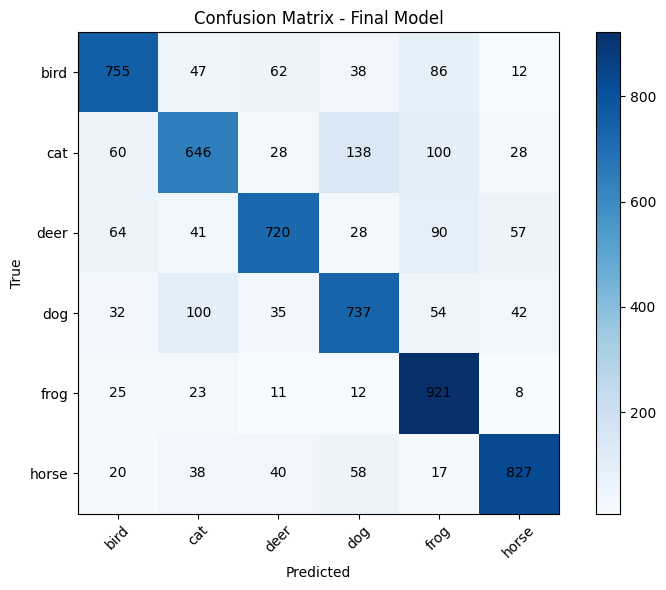


Classification Report:
              precision    recall  f1-score   support

        bird       0.79      0.76      0.77      1000
         cat       0.72      0.65      0.68      1000
        deer       0.80      0.72      0.76      1000
         dog       0.73      0.74      0.73      1000
        frog       0.73      0.92      0.81      1000
       horse       0.85      0.83      0.84      1000

    accuracy                           0.77      6000
   macro avg       0.77      0.77      0.77      6000
weighted avg       0.77      0.77      0.77      6000



In [ ]:
# Evaluate final model on the test set 
test_loss, test_acc = model_transfer.evaluate(x_test_resized, y_test_animals, verbose=0)
print(f"Final Test Accuracy: {test_acc:.3f}")
print(f"Final Test Loss:     {test_loss:.3f}")

# Save the model
model_transfer.save('models/final_model.keras')
print("\nModel saved to models/final_model.keras")

# Make predictions on test set
y_pred_probs = model_transfer.predict(x_test_resized, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_animals.flatten()

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(6), animal_names, rotation=45)
plt.yticks(range(6), animal_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Final Model')
for i in range(6):
    for j in range(6):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='black')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=animal_names))

ValueError: Attempt to convert a value (None) with an unsupported type (<class 'NoneType'>) to a Tensor.

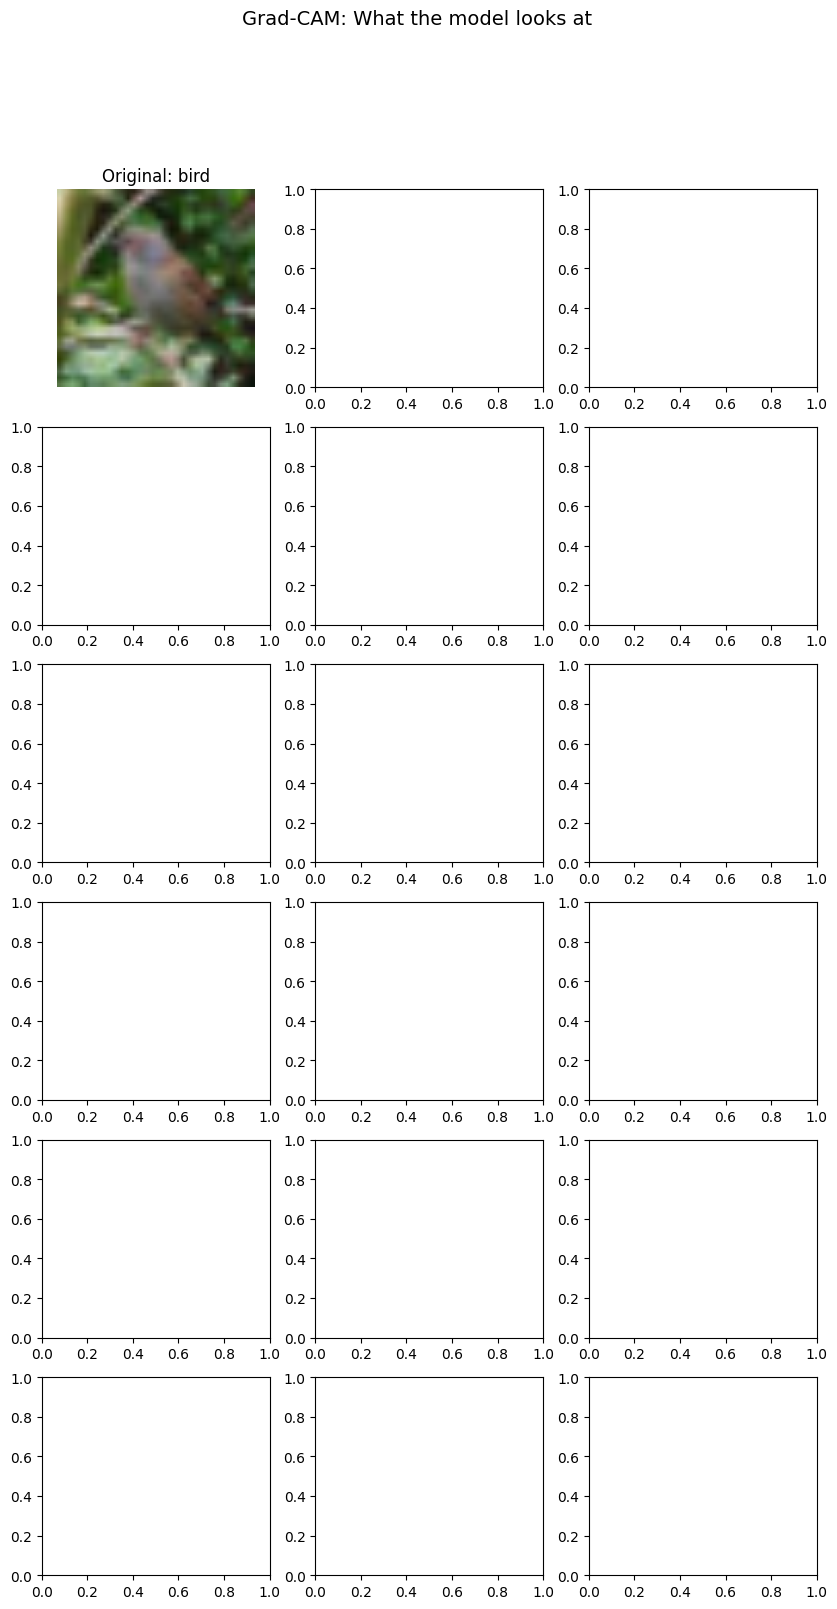

In [17]:
import tensorflow as tf

def make_gradcam_heatmap(img_array, model):
    # Get the last conv layer inside MobileNetV2
    mobilenet = model.get_layer('mobilenetv2_1.00_96')
    last_conv_layer = mobilenet.get_layer('Conv_1')
    
    # Build a model that outputs both conv features and predictions
    conv_model = tf.keras.Model(inputs=mobilenet.inputs, 
                                outputs=last_conv_layer.output)
    
    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_outputs = conv_model(img_tensor)
        tape.watch(conv_outputs)
        pred = model(img_tensor)
        pred_index = tf.argmax(pred[0])
        class_channel = pred[:, pred_index]
    
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Show Grad-CAM for one image per class
fig, axes = plt.subplots(6, 3, figsize=(10, 18))
fig.suptitle('Grad-CAM: What the model looks at', fontsize=14)

for class_idx in range(6):
    class_mask = (y_true == class_idx) & (y_pred == class_idx)
    if not np.any(class_mask):
        continue
    idx = np.where(class_mask)[0][0]
    img = x_test_resized[idx]
    img_array = tf.expand_dims(img, 0)

    axes[class_idx, 0].imshow(img)
    axes[class_idx, 0].set_title(f'Original: {animal_names[class_idx]}')
    axes[class_idx, 0].axis('off')

    heatmap = make_gradcam_heatmap(img_array, model_transfer)
    axes[class_idx, 1].imshow(heatmap, cmap='jet')
    axes[class_idx, 1].set_title('Heatmap')
    axes[class_idx, 1].axis('off')

    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], (96, 96)).numpy().squeeze()
    overlay = img.numpy().copy()
    overlay[:,:,0] = np.clip(overlay[:,:,0] + heatmap_resized * 0.4, 0, 1)
    axes[class_idx, 2].imshow(overlay)
    axes[class_idx, 2].set_title('Overlay')
    axes[class_idx, 2].axis('off')

plt.tight_layout()
plt.savefig('outputs/gradcam_visualization.png')
plt.show()
print("Grad-CAM saved!")

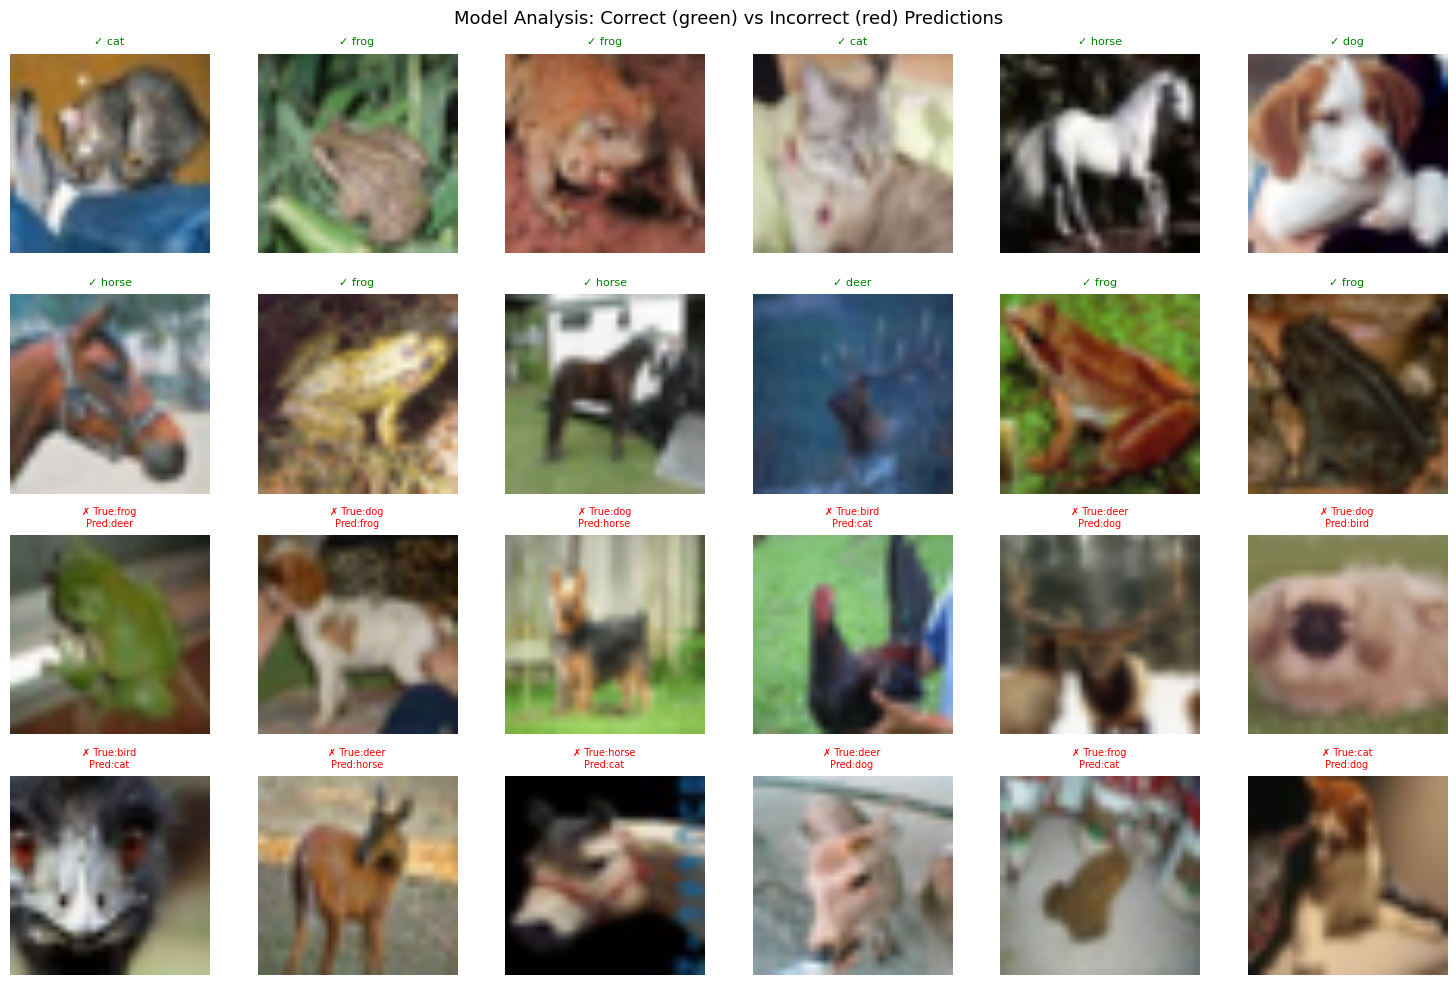

Analysis saved!


In [18]:
# Show correct and incorrect predictions - equally valid model analysis!
fig, axes = plt.subplots(4, 6, figsize=(15, 10))
fig.suptitle('Model Analysis: Correct (green) vs Incorrect (red) Predictions', fontsize=13)

correct_shown = 0
incorrect_shown = 0

for i in range(len(y_true)):
    if correct_shown < 12:
        if y_pred[i] == y_true[i]:
            ax = axes[correct_shown // 6][correct_shown % 6]
            ax.imshow(x_test_resized[i])
            ax.set_title(f'✓ {animal_names[y_true[i]]}', color='green', fontsize=8)
            ax.axis('off')
            correct_shown += 1
    if incorrect_shown < 12:
        if y_pred[i] != y_true[i]:
            ax = axes[2 + incorrect_shown // 6][incorrect_shown % 6]
            ax.imshow(x_test_resized[i])
            ax.set_title(f'✗ True:{animal_names[y_true[i]]}\nPred:{animal_names[y_pred[i]]}', 
                        color='red', fontsize=7)
            ax.axis('off')
            incorrect_shown += 1
    if correct_shown >= 12 and incorrect_shown >= 12:
        break

plt.tight_layout()
plt.savefig('outputs/correct_vs_incorrect.png')
plt.show()
print("Analysis saved!")

## Section 8: Conclusions

### Summary of Results

| Model | Validation Accuracy |
|-------|-------------------|
| Baseline CNN | 67.5% |
| Dropout CNN | 70.9% |
| Augmented CNN | 67.2% |
| Transfer Learning (MobileNetV2) | **76.2%** |

### Key Findings
1. **Overfitting**: The baseline model showed severe overfitting (86% train vs 67% val). Dropout reduced this gap from 19% to 2.7%.
2. **Best regularisation**: Dropout outperformed data augmentation alone in this setting.
This is probably because CIFAR-10 images are very small 32×32 pixels. When we apply 
   rotations and zoom, the images lose important details because there are not many pixels 
   to start with. Dropout works better here because it does not change the images  it only 
   changes how the network learns from them.
3. **Hyperparameters**: Learning rate 0.001 was optimal  0.01 was too unstable, 0.0001 too slow.
4. **Transfer learning**: MobileNetV2 pretrained on ImageNet achieved 77% test accuracy, outperforming all models trained from scratch.
5. **Hardest class**: Cat was the most difficult to classify (65% recall), often confused with dog.
6. **Easiest class**: Frog was easiest (92% recall), likely due to its distinctive green colour.

### References
- Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.
- CIFAR-10 dataset: Krizhevsky, A. (2009). Learning Multiple Layers of Features from Tiny Images.
- MobileNetV2: Sandler et al. (2018). MobileNetV2: Inverted Residuals and Linear Bottlenecks.
- TensorFlow/Keras documentation: https://www.tensorflow.org

In [ ]:
print(f"Final test accuracy: 77%")
print("All outputs saved to the outputs/ folder")
import os
print("\nOutput files:")
for f in os.listdir('outputs'):
    print(f"  - {f}")

Final test accuracy: 77%
All outputs saved to the outputs/ folder

Output files:


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'outputs'